In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configure visualizations
sns.set(style="whitegrid")

df = pd.read_csv('dataset.csv')

In [ ]:
# Check the basic structure of the dataset
print("Dataset Info:")
df.info() 

print("\nSummary Statistics:")
print(df.describe()) 

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       902 non-null    int64
 1   Attrition                 902 non-null    str  
 2   BusinessTravel            902 non-null    str  
 3   DailyRate                 902 non-null    int64
 4   Department                902 non-null    str  
 5   DistanceFromHome          902 non-null    int64
 6   Education                 902 non-null    int64
 7   EducationField            902 non-null    str  
 8   EmployeeCount             902 non-null    int64
 9   EmployeeNumber            902 non-null    int64
 10  EnvironmentSatisfaction   902 non-null    int64
 11  Gender                    902 non-null    str  
 12  HourlyRate                902 non-null    int64
 13  JobInvolvement            902 non-null    int64
 14  JobLevel                  902 non-null 

In [ ]:
# Check for any missing values in the dataset
print("\nMissing Values:")
print(df.isnull().sum())  
# Explore the target variable (binary classification)
print("\nTarget Variable Distribution:")
print(df['Attrition'].value_counts())  # Distribution of the target classes



Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

In [5]:
# Measure and print the number of unique values for each column.
# Check if there are any columns with less than 2 unique values. If so, remove them.

unique_counts= {}
for col in df:
    unique_counts[col]= df[col].nunique()
print(unique_counts)

print("colmuns with less than 2 unique values: ")
for key, value in unique_counts.items():
    if value<2:
        print(key)
        df.drop(key, axis= 1, inplace= True)


{'Age': 42, 'Attrition': 2, 'BusinessTravel': 3, 'DailyRate': 653, 'Department': 3, 'DistanceFromHome': 29, 'Education': 5, 'EducationField': 6, 'EmployeeCount': 1, 'EmployeeNumber': 902, 'EnvironmentSatisfaction': 4, 'Gender': 2, 'HourlyRate': 71, 'JobInvolvement': 4, 'JobLevel': 5, 'JobRole': 9, 'JobSatisfaction': 4, 'MaritalStatus': 3, 'MonthlyIncome': 853, 'MonthlyRate': 888, 'NumCompaniesWorked': 10, 'Over18': 1, 'OverTime': 2, 'PercentSalaryHike': 15, 'PerformanceRating': 2, 'RelationshipSatisfaction': 4, 'StandardHours': 1, 'StockOptionLevel': 4, 'TotalWorkingYears': 40, 'TrainingTimesLastYear': 7, 'WorkLifeBalance': 4, 'YearsAtCompany': 34, 'YearsInCurrentRole': 19, 'YearsSinceLastPromotion': 16, 'YearsWithCurrManager': 17}
colmuns with less than 2 unique values: 
EmployeeCount
Over18
StandardHours


Highest Average Income:  Sales
Lowest Average Income:  Research & Development


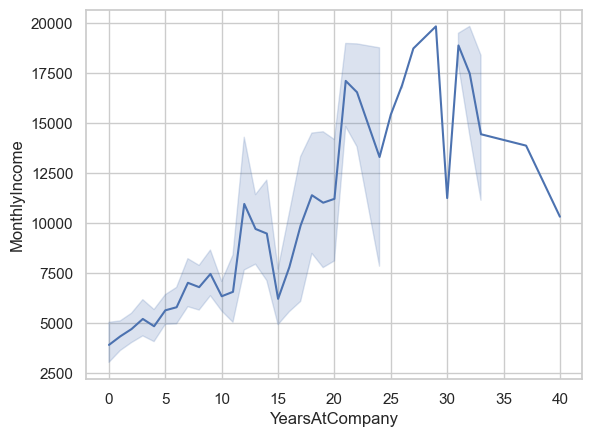

In [6]:
sns.lineplot(data= df, x= 'YearsAtCompany', y= 'MonthlyIncome')
print('Highest Average Income: ', df.groupby('Department')['MonthlyIncome'].mean().idxmax())
print('Lowest Average Income: ',df.groupby('Department')['MonthlyIncome'].mean().idxmin())

In [ ]:
# Label encode all categorical columns

encoded_df = df.copy()

for col in encoded_df.columns:
    if encoded_df[col].dtype == 'str':
        encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col])
        


In [14]:
encoded_df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,29,0,2,592,1,7,3,1,1883,4,...,3,2,0,11,2,3,3,2,1,2
1,34,0,2,1326,2,3,3,4,1478,4,...,3,4,0,15,2,3,13,9,3,12
2,27,0,2,954,2,9,3,2,1965,4,...,3,1,0,7,5,3,7,7,0,7
3,32,0,2,929,2,10,3,2,722,4,...,3,4,0,10,2,2,10,7,0,8
4,50,0,1,1234,1,20,5,3,1606,2,...,3,3,1,32,3,3,30,8,12,13


In [ ]:
X = encoded_df.drop(columns=['Attrition'])
y = encoded_df['Attrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [17]:
print(X_train.dtypes)

Age                         int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLast

In [18]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K-Nearest Neighbors Model

In [19]:
from collections import Counter

class CustomKNN:
    def __init__(self, k=3):
        """
        Initialize the KNN classifier.

        Parameters:
        - k (int): Number of neighbors to consider.
        """
        # Store the number of neighbors (k)
        self.k = k

    def fit(self, X_train, y_train):
        """
        Fit the KNN classifier to the training data.

        Parameters:
        - X_train (numpy array): Training feature vectors.
        - y_train (numpy array): Training labels.
        """
        # Store training data
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def euclidean_distance(self, x1, x2):
        """
        Calculate the Euclidean distance between two data points.

        Parameters:
        - x1 (numpy array): First data point.
        - x2 (numpy array): Second data point.

        Returns:
        - float: Euclidean distance between x1 and x2.
        """
        # Calculate and return the Euclidean distance
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X_test):
        """
        Predict labels for test data.

        Parameters:
        - X_test (numpy array): Test feature vectors.

        Returns:
        - numpy array: Predicted labels.
        """
        # Predict label for each test instance and return the array of predictions
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)
    

    def _predict(self, x):
        """
        Predict label for a single data point.

        Parameters:
        - x (numpy array): Test data point.

        Returns:
        - int: Predicted label.
        """
        # Compute distances from x to all training points
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]

        # Find the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get the labels of the k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return the most common label among the k nearest neighbors (majority vote)
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [20]:
# Optional. You can choose any range of k values that you want.
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []
models= []

# Fit the model using the scaled training data
# Make predictions on the scaled test data
# Evaluate the model's accuracy for each value of k and choose the best one
for k in k_values:
  my_model= CustomKNN(k)
  my_model.fit(X_train_scaled, y_train)
  y_pred_custom= my_model.predict(X_test_scaled)
  accuracy= accuracy_score(y_test, y_pred_custom)
  print(f'k: {k} - Accuracy: {accuracy}')
  models.append(my_model)
  accuracies.append(accuracy)

best_custom_model= models[np.argmax(accuracies)]
# Keep the best k value (needed later on with bagging)
bestk= k_values[np.argmax(accuracies)]

k: 1 - Accuracy: 0.7527675276752768
k: 3 - Accuracy: 0.7785977859778598
k: 5 - Accuracy: 0.8007380073800738
k: 7 - Accuracy: 0.8044280442804428
k: 9 - Accuracy: 0.8007380073800738
k: 11 - Accuracy: 0.8191881918819188
k: 13 - Accuracy: 0.7933579335793358
k: 15 - Accuracy: 0.8007380073800738


In [21]:

# Print the accuracy and classification report using sklearn's metrics for your best model
y_pred= best_custom_model.predict(X_test_scaled)
print("Model's Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Model's Accuracy: 0.8191881918819188
              precision    recall  f1-score   support

           0       0.82      0.99      0.90       214
           1       0.83      0.18      0.29        57

    accuracy                           0.82       271
   macro avg       0.83      0.58      0.59       271
weighted avg       0.82      0.82      0.77       271



Evaluation

In [ ]:
eval_df= pd.read_csv('test.csv')
eval_df= scaler.transform(eval_df)
# Prediction
y_pred_eval= best_custom_model.predict(eval_df)
     

# Save the results as a csv file
result_df= pd.DataFrame()
result_df['target']=pd.Series(y_pred_eval)
result_df.to_csv('result.csv', index= False)

Random Forest Model

In [26]:
# Random Forest Model Implementation
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning for Random Forest
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
rf_cv = GridSearchCV(rf, param_grid_rf, cv=5)
rf_cv.fit(X_train, y_train)

# Best Random Forest model
best_rf = rf_cv.best_estimator_

# Prediction and evaluation
y_pred_rf = best_rf.predict(X_test)

# Print Random Forest model accuracy and classification report
print("Random Forest Model Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.8302583025830258
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       214
           1       0.74      0.30      0.42        57

    accuracy                           0.83       271
   macro avg       0.79      0.64      0.66       271
weighted avg       0.82      0.83      0.80       271



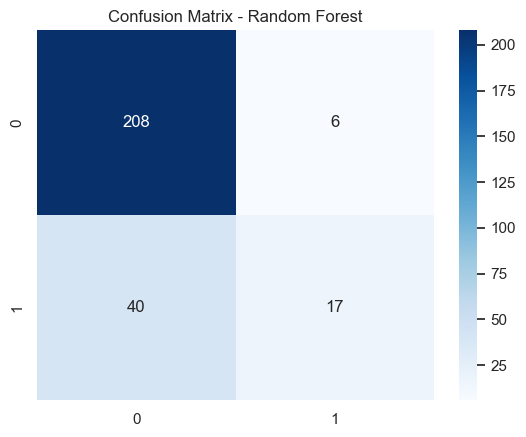

In [27]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

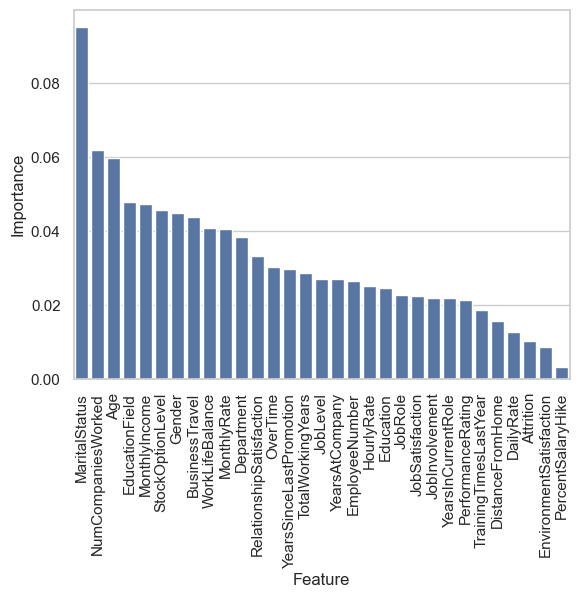

In [28]:
imps= best_rf.feature_importances_
indices= np.argsort(imps)[::-1]
importance_df= pd.DataFrame({'Feature': df.columns[indices], 'Importance': imps[indices]})

sns.barplot(data= importance_df, x='Feature', y='Importance').tick_params(axis='x', rotation=90)

AdaBoost Model

In [29]:
# AdaBoost Model Implementation
adaboost = AdaBoostClassifier(random_state=42)

# Hyperparameter tuning for AdaBoost
param_grid_ada = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 1.0]}
adaboost_cv = GridSearchCV(adaboost, param_grid_ada, cv=5)
adaboost_cv.fit(X_train, y_train)

# Best AdaBoost model
best_adaboost = adaboost_cv.best_estimator_

# Prediction and evaluation
y_pred_adaboost = best_adaboost.predict(X_test)

# Print AdaBoost model accuracy and classification report
print("AdaBoost Model Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print(classification_report(y_test, y_pred_adaboost))

AdaBoost Model Accuracy: 0.8265682656826568
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       214
           1       0.63      0.42      0.51        57

    accuracy                           0.83       271
   macro avg       0.74      0.68      0.70       271
weighted avg       0.81      0.83      0.81       271



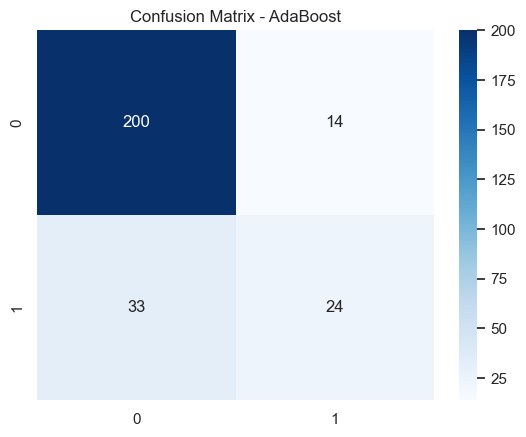

In [30]:
# Confusion Matrix for AdaBoost
cm_adaboost = confusion_matrix(y_test, y_pred_adaboost)
sns.heatmap(cm_adaboost, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

Model Comparison


Model Comparison Table:
           Model  Accuracy
0            KNN  0.819188
1  Random Forest  0.830258
2       AdaBoost  0.826568


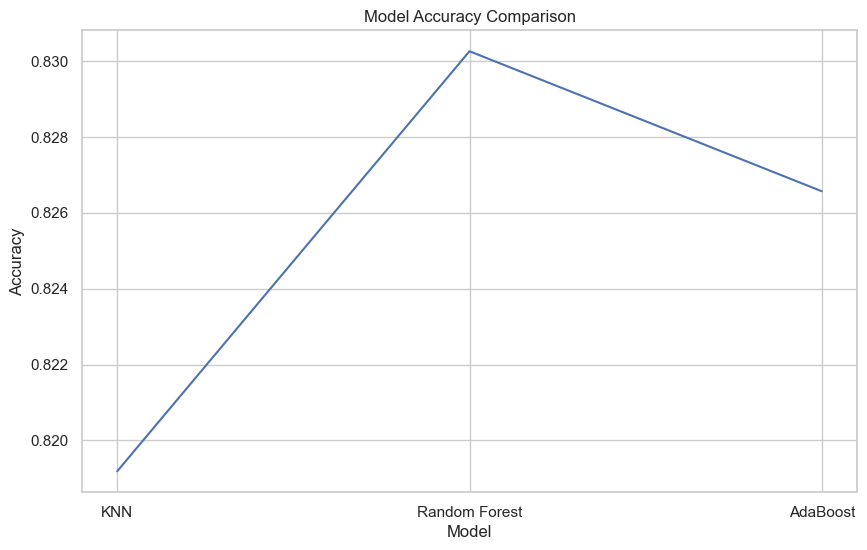

In [ ]:
#a table comparing all the models' accuracy
models = ['KNN', 'Random Forest', 'AdaBoost']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_adaboost)
]

accuracy_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

# Display the comparison table
print("\nModel Comparison Table:")
print(accuracy_df)

# Plotting model accuracies for comparison
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=accuracy_df)
plt.title('Model Accuracy Comparison')
plt.show()
     